In [1]:
%matplotlib inline
from roboflow import Roboflow
import os
import random
import shutil
import yaml

rf = Roboflow(api_key="9X8ClVkM9agUJAH3hcAN")
project = rf.workspace("hard-drive").project("electronic_devices_local")
version = project.version(1)
dataset = version.download("yolov8")

DATA_PATH = dataset.location
OUTPUT_DIR = "dataset_rfdetr_box_640"

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "labels"), exist_ok=True)

images_dir = os.path.join(DATA_PATH, "train", "images")
labels_dir = os.path.join(DATA_PATH, "train", "labels")

images = sorted([name for name in os.listdir(images_dir) if name.lower().endswith(".jpg")])
random.seed(42)
random.shuffle(images)

train_idx = int(len(images) * 0.8)
valid_idx = int(len(images) * 0.9)
splits = {
    "train": images[:train_idx],
    "valid": images[train_idx:valid_idx],
    "test": images[valid_idx:],
}

for split_name, image_names in splits.items():
    for image_name in image_names:
        shutil.copy(
            os.path.join(images_dir, image_name),
            os.path.join(OUTPUT_DIR, split_name, "images", image_name),
        )

        label_name = os.path.splitext(image_name)[0] + ".txt"
        label_src = os.path.join(labels_dir, label_name)
        label_dest = os.path.join(OUTPUT_DIR, split_name, "labels", label_name)

        converted_lines = []
        if os.path.exists(label_src):
            with open(label_src, "r") as label_file:
                for raw_line in label_file:
                    parts = raw_line.strip().split()
                    if len(parts) < 5:
                        continue

                    class_id = parts[0]
                    coords = [float(value) for value in parts[1:]]

                    if len(coords) == 4:
                        cx, cy, width, height = coords
                    else:
                        if len(coords) % 2 != 0:
                            continue
                        xs = coords[0::2]
                        ys = coords[1::2]
                        min_x, max_x = min(xs), max(xs)
                        min_y, max_y = min(ys), max(ys)
                        cx = (min_x + max_x) / 2.0
                        cy = (min_y + max_y) / 2.0
                        width = max_x - min_x
                        height = max_y - min_y

                    converted_lines.append(
                        f"{class_id} {cx:.6f} {cy:.6f} {width:.6f} {height:.6f}"
                    )

        with open(label_dest, "w") as output_label_file:
            if converted_lines:
                output_label_file.write("\n".join(converted_lines) + "\n")
            else:
                output_label_file.write("")

with open(os.path.join(DATA_PATH, "data.yaml"), "r") as source_yaml_file:
    data_yaml = yaml.safe_load(source_yaml_file)

data_yaml["train"] = "train/images"
data_yaml["val"] = "valid/images"
data_yaml["test"] = "test/images"

with open(os.path.join(OUTPUT_DIR, "data.yaml"), "w") as output_yaml_file:
    yaml.dump(data_yaml, output_yaml_file)

print(f"✅ Dataset split and converted. Segmentation polygons mapped to bounding boxes in {OUTPUT_DIR}/")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Electronic_Devices_Local-1 in yolov8:: 100%|██████████| 5603/5603 [00:00<00:00, 15807.56it/s]


✅ Dataset split and converted. Segmentation polygons mapped to bounding boxes in dataset_rfdetr_box_640/


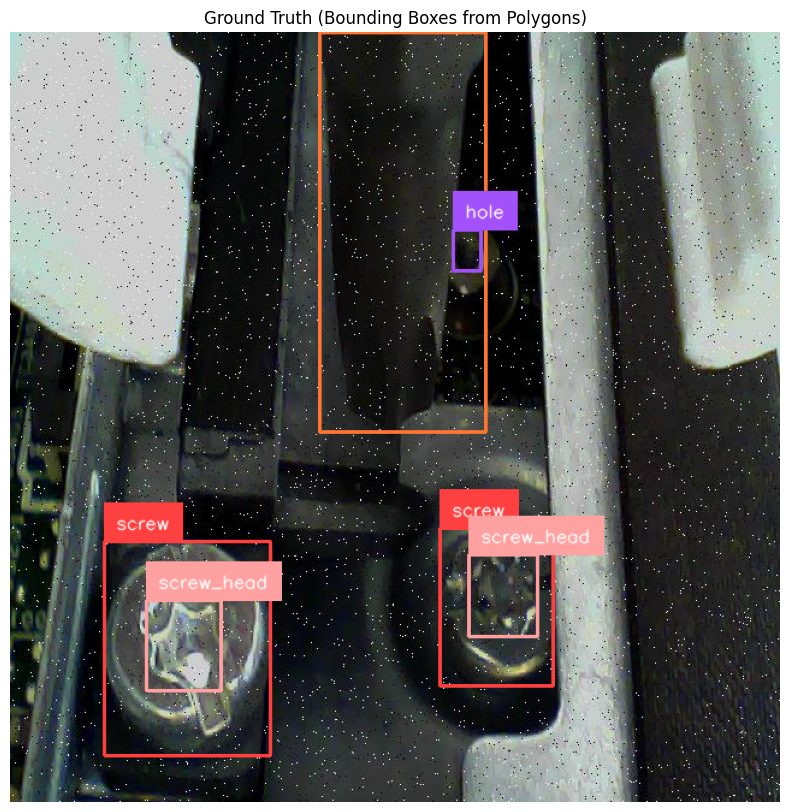

In [2]:
import supervision as sv
import cv2
import matplotlib.pyplot as plt

dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=os.path.join(OUTPUT_DIR, "train", "images"),
    annotations_directory_path=os.path.join(OUTPUT_DIR, "train", "labels"),
    data_yaml_path=os.path.join(OUTPUT_DIR, "data.yaml"),
)

image_name, image, annotations = dataset[0]

box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator()

with open(os.path.join(OUTPUT_DIR, "data.yaml"), "r") as source_yaml_file:
    classes = yaml.safe_load(source_yaml_file)["names"]

labels = [classes[class_id] for class_id in annotations.class_id]

annotated_image = box_annotator.annotate(scene=image.copy(), detections=annotations)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=annotations, labels=labels)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Ground Truth (Bounding Boxes from Polygons)")
plt.show()


In [ ]:
from rfdetr import RFDETRSmall

model = RFDETRSmall()
RUN_DIR = "runs/train/rfdetr_box_640_fixed"

model.train(
    dataset_dir=OUTPUT_DIR,
    output_dir=RUN_DIR,
    epochs=100,
    batch_size=16,
    num_workers=8,
    grad_accum_steps=1,
    resolution=640,
)


In [ ]:
import json
import pandas as pd

log_file = os.path.join(RUN_DIR, "log.txt")

if os.path.exists(log_file):
    records = []
    with open(log_file, "r") as log_stream:
        for line in log_stream:
            try:
                records.append(json.loads(line.strip()))
            except json.JSONDecodeError:
                continue

    df = pd.DataFrame(records)

    if "test_coco_eval_bbox" in df.columns:
        best_box_map = df["test_coco_eval_bbox"].dropna().apply(lambda value: value[0]).max()
        print(f"🏆 Best Bounding Box mAP (50-95): {best_box_map:.4f}")
    else:
        print("Metrics loaded successfully. Available columns:")
        print(df.columns.tolist())
else:
    print("❌ log.txt file not found. Ensure training completed.")


In [ ]:
import matplotlib.image as mpimg

plot_path = os.path.join(RUN_DIR, "metrics_plot.png")

if os.path.exists(plot_path):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(plot_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title("RF-DETR Training Metrics", fontsize=16)
    plt.show()
else:
    print(f"⚠️ {plot_path} not found.")


In [ ]:
if "df" in locals() and not df.empty:
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    if "train_loss_bbox" in df.columns:
        plt.plot(df["epoch"], df["train_loss_bbox"], label="Train Box Loss", color="blue")
    plt.title("RF-DETR Bounding Box Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    if "train_loss_ce" in df.columns:
        plt.plot(df["epoch"], df["train_loss_ce"], label="Train Class Loss", color="purple")
    plt.title("Classification Loss (Cross Entropy)")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 3, 3)
    if "test_coco_eval_bbox" in df.columns:
        eval_data = df.dropna(subset=["test_coco_eval_bbox"])
        map_scores = eval_data["test_coco_eval_bbox"].apply(lambda value: value[0])
        plt.plot(eval_data["epoch"], map_scores, label="Box mAP 50-95", color="green", linewidth=2)
    plt.title("Mean Average Precision (mAP 0.5:0.95)")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("❌ Dataframe 'df' not found. Run the log parsing cell first.")


In [ ]:
from PIL import Image
import numpy as np

weights_path = os.path.join(RUN_DIR, "checkpoint_best_ema.pth")
model = RFDETRSmall(pretrain_weights=weights_path, resolution=640)

test_images_dir = os.path.join(OUTPUT_DIR, "test", "images")
test_img_path = os.path.join(test_images_dir, os.listdir(test_images_dir)[0])
pil_image = Image.open(test_img_path)

detections = model.predict(pil_image, threshold=0.4)
cv_image = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_padding=10)

labels = [
    f"{classes[class_id]} {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

annotated_image = box_annotator.annotate(scene=cv_image.copy(), detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("RF-DETR Box Inference (640px)")
plt.show()
